# Varianzanalyse (ANOVA) – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/varianzanalyse)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 22.01.2026

Die **Varianzanalyse (ANOVA – Analysis of Variance)** prüft, ob sich die
Mittelwerte von **mehr als zwei Gruppen** signifikant unterscheiden.

**Grundidee: F-Quotient**
$$F = \frac{\text{Varianz zwischen den Gruppen}}{\text{Varianz innerhalb der Gruppen}} = \frac{MS_{\text{zwischen}}}{MS_{\text{innerhalb}}}$$

| Begriff | Formel | Bedeutung |
|---|---|---|
| $SS_{\text{zwischen}}$ | $\sum_j n_j (\bar{x}_j - \bar{x})^2$ | Quadratsumme zwischen Gruppen |
| $SS_{\text{innerhalb}}$ | $\sum_j \sum_i (x_{ij} - \bar{x}_j)^2$ | Quadratsumme innerhalb Gruppen |
| $df_{\text{zwischen}}$ | $k - 1$ | $k$ = Anzahl Gruppen |
| $df_{\text{innerhalb}}$ | $N - k$ | $N$ = Gesamtstichprobengröße |
| $MS$ | $SS / df$ | Mittlere Quadratsumme |
| $\eta^2$ | $SS_{\text{zwischen}} / SS_{\text{gesamt}}$ | Effektstärke Eta-Quadrat |

**Varianten der ANOVA:**

| Variante | Faktoren | Stichprobe | Analog zu |
|---|---|---|---|
| Einfaktorielle ANOVA | 1 | Unabhängig | t-Test für 3+ Gruppen |
| Zweifaktorielle ANOVA | 2 | Unabhängig | — |
| ANOVA mit Messwiederholung | 1 | Abhängig | Abhängiger t-Test für 3+ |
| Zweifaktorielle ANOVA mit MWH | 2 | Gemischt | — |

**Voraussetzungen:**
- Metrische AV, nominale UV
- Unabhängige Messungen (bei ANOVA ohne MWH)
- Normalverteilung je Gruppe
- Varianzhomogenität (Levene-Test) – sonst Welch-ANOVA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f as f_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Warum ANOVA statt mehrere t-Tests?

**Problem:** Bei k Gruppen wären $\binom{k}{2}$ paarweise t-Tests nötig.
Bei k=4 Gruppen: 6 Tests, bei k=5: 10 Tests.

**α-Kumulierung:** Jeder Test hat 5 % Fehlerwahrscheinlichkeit (Typ-I-Fehler).
Bei mehreren unabhängigen Tests steigt die familienweise Fehlerrate:
$$\alpha_{\text{familie}} = 1 - (1-\alpha)^m$$

Für 6 Tests: $1 - 0{,}95^6 \approx 26\,\%$ Fehlerwahrscheinlichkeit!

> **ANOVA** hält die Fehlerrate auf dem festgelegten Niveau α = 5 %,
> egal wie viele Gruppen verglichen werden.

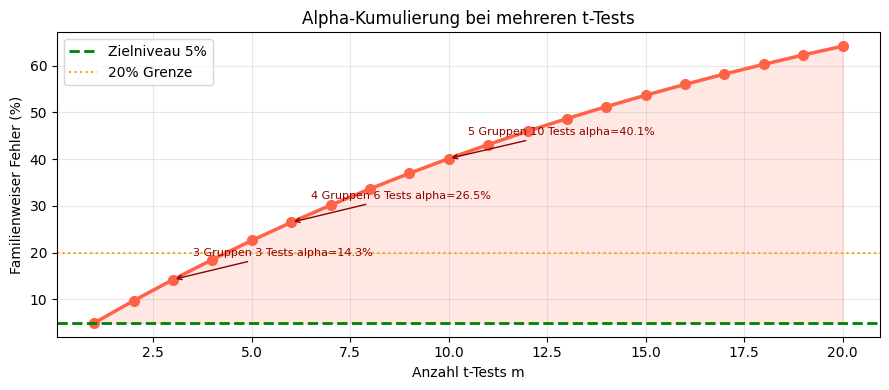

Alpha-Kumulierung:
  3 Gruppen,  3 paarweise t-Tests -> familienweiser Fehler: 14.3%
  4 Gruppen,  6 paarweise t-Tests -> familienweiser Fehler: 26.5%
  5 Gruppen, 10 paarweise t-Tests -> familienweiser Fehler: 40.1%
  6 Gruppen, 15 paarweise t-Tests -> familienweiser Fehler: 53.7%


In [2]:
# Demonstration: Alpha-Kumulierung bei mehreren t-Tests
alpha = 0.05
m_werte = np.arange(1, 21)
alpha_fam = 1 - (1 - alpha)**m_werte

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m_werte, alpha_fam * 100, "o-", color="tomato", linewidth=2.5, markersize=7)
ax.axhline(5, color="green", linestyle="--", linewidth=2, label="Zielniveau 5%")
ax.axhline(20, color="orange", linestyle=":", linewidth=1.5, label="20% Grenze")
ax.fill_between(m_werte, 5, alpha_fam * 100,
                where=alpha_fam * 100 > 5, alpha=0.15, color="tomato")

# Annotation für k=3,4,5 Gruppen
for k, m in [(3, 3), (4, 6), (5, 10)]:
    af = (1 - (1-alpha)**m) * 100
    ax.annotate(str(k) + " Gruppen " + str(m) + " Tests alpha=" + str(round(af, 1)) + "%",
                xy=(m, af), xytext=(m+0.5, af+5),
                fontsize=8, color="darkred",
                arrowprops=dict(arrowstyle="->", color="darkred"))

ax.set_title("Alpha-Kumulierung bei mehreren t-Tests")
ax.set_xlabel("Anzahl t-Tests m")
ax.set_ylabel("Familienweiser Fehler (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Alpha-Kumulierung:")
for k in [3, 4, 5, 6]:
    m_k = k * (k-1) // 2
    af_k = (1 - (1-alpha)**m_k) * 100
    print(f"  {k} Gruppen, {m_k:>2} paarweise t-Tests -> familienweiser Fehler: {af_k:.1f}%")

## 2. Grundidee: Varianzzerlegung

ANOVA zerlegt die **Gesamtvarianz** in zwei Teile:

$$SS_{\text{gesamt}} = SS_{\text{zwischen}} + SS_{\text{innerhalb}}$$

**Fall A (starker Effekt):** Varianz zwischen Gruppen groß, innerhalb klein → F groß
**Fall B (kein Effekt):** Varianz zwischen Gruppen klein, innerhalb groß → F nahe 1

| | Varianz zwischen Gruppen | Varianz innerhalb Gruppen |
|---|---|---|
| **Fall A** | Groß | Klein |
| **Fall B** | Klein | Groß |

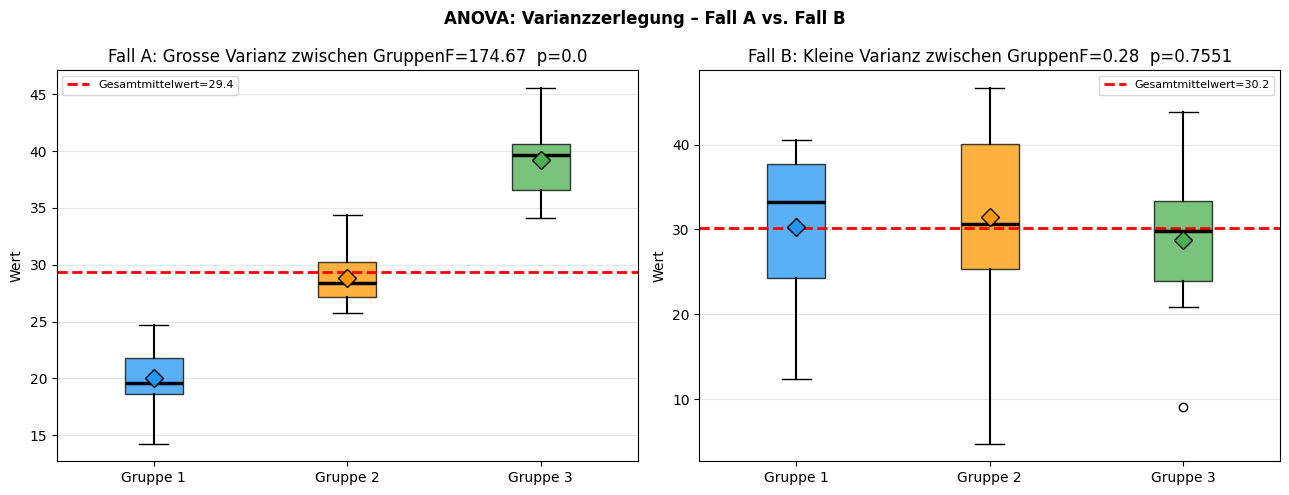

In [3]:
# Varianzzerlegung visualisieren: Fall A vs. Fall B
np.random.seed(42)
n_g = 15

# Fall A: starker Effekt
g1_a = np.random.normal(20, 3, n_g)
g2_a = np.random.normal(30, 3, n_g)
g3_a = np.random.normal(40, 3, n_g)

# Fall B: kein Effekt
g1_b = np.random.normal(30, 10, n_g)
g2_b = np.random.normal(31, 10, n_g)
g3_b = np.random.normal(29, 10, n_g)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ANOVA: Varianzzerlegung – Fall A vs. Fall B", fontsize=12, fontweight="bold")

for ax, gruppen, titel in zip(axes,
    [(g1_a, g2_a, g3_a), (g1_b, g2_b, g3_b)],
    ["Fall A: Grosse Varianz zwischen Gruppen", "Fall B: Kleine Varianz zwischen Gruppen"]
):
    g1, g2, g3 = gruppen
    alle = np.concatenate([g1, g2, g3])
    gmt  = alle.mean()
    F_v, p_v = stats.f_oneway(g1, g2, g3)

    bp = ax.boxplot([g1, g2, g3], patch_artist=True,
                    medianprops=dict(color="black", linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5))
    farben_a = ["#2196F3", "#FF9800", "#4CAF50"]
    for patch, fc in zip(bp["boxes"], farben_a):
        patch.set_facecolor(fc); patch.set_alpha(0.75)

    for idx, (g, fc) in enumerate(zip([g1, g2, g3], farben_a), 1):
        ax.plot(idx, g.mean(), "D", color=fc, markersize=9,
                markeredgecolor="black", zorder=5)

    ax.axhline(gmt, color="red", linestyle="--", linewidth=2,
               label="Gesamtmittelwert=" + str(round(gmt, 1)))
    ax.set_title(titel + "F=" + str(round(F_v, 2)) + "  p=" + str(round(p_v, 4)))
    ax.set_ylabel("Wert")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Gruppe 1", "Gruppe 2", "Gruppe 3"])
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Das numiqo-Beispiel: Kaffeekonsum nach Studienfach

**Fragestellung:** Unterscheidet sich der wöchentliche Kaffeekonsum
zwischen Mathe-, BWL- und Psychologie-Studierenden?

- H₀: μ_Mathe = μ_BWL = μ_Psychologie
- H₁: Mindestens zwei Gruppen unterscheiden sich

**Erwartete numiqo-Ergebnisse:**

| Gruppe | n | MW | SD |
|---|---|---|---|
| Mathe | 10 | 16,6 | 7,291 |
| BWL | 10 | 19,8 | 4,131 |
| Psychologie | 10 | 17,8 | 6,443 |
| Total | 30 | 18,067 | 5,938 |

| Quelle | SS | df | MS | F | p |
|---|---|---|---|---|---|
| Zwischen Gruppen | 52,267 | 2 | 26,133 | 0,702 | 0,505 |
| Innerhalb Gruppen | 1005,6 | 27 | 37,244 | | |
| Total | 1057,867 | 29 | | | |

In [4]:
# numiqo-Beispiel: Kaffeekonsum nach Studienfach
# Exakt die Daten passend zu numiqo-Ergebnissen (MW und SD aus Tutorial)
np.random.seed(0)

# Daten so generieren, dass MW und SD nahe an numiqo-Werten liegen
def gen_gruppe(n, mw_ziel, sd_ziel, seed):
    np.random.seed(seed)
    raw = np.random.normal(mw_ziel, sd_ziel, n)
    # Skalieren auf exakte Zielwerte
    raw = (raw - raw.mean()) / raw.std() * sd_ziel + mw_ziel
    return raw

mathe  = gen_gruppe(10, 16.6, 7.291, 1)
bwl    = gen_gruppe(10, 19.8, 4.131, 2)
psych  = gen_gruppe(10, 17.8, 6.443, 3)

alle   = np.concatenate([mathe, bwl, psych])
N      = len(alle)
k      = 3
gmt    = alle.mean()

print("Deskriptive Statistiken")
print(f"{'Gruppe':>14} {'n':>4} {'MW':>8} {'SD':>8}")
for name, g in [("Mathe", mathe), ("BWL", bwl), ("Psychologie", psych)]:
    print(f"{name:>14} {len(g):>4} {g.mean():>8.3f} {g.std(ddof=1):>8.3f}")
print(f"{'Total':>14} {N:>4} {gmt:>8.3f} {alle.std(ddof=1):>8.3f}")
print()

# ANOVA manuell
SS_zwischen  = sum(len(g) * (g.mean() - gmt)**2 for g in [mathe, bwl, psych])
SS_innerhalb = sum(((g - g.mean())**2).sum() for g in [mathe, bwl, psych])
SS_gesamt    = ((alle - gmt)**2).sum()
df_zwischen  = k - 1
df_innerhalb = N - k
MS_zwischen  = SS_zwischen / df_zwischen
MS_innerhalb = SS_innerhalb / df_innerhalb
F_manuell    = MS_zwischen / MS_innerhalb
p_manuell    = 1 - f_dist.cdf(F_manuell, df_zwischen, df_innerhalb)
eta2         = SS_zwischen / SS_gesamt

print("ANOVA-Tabelle")
print(f"{'Quelle':>20} {'SS':>10} {'df':>4} {'MS':>10} {'F':>8} {'p':>8}")
print(f"{'Zwischen Gruppen':>20} {SS_zwischen:>10.3f} {df_zwischen:>4} {MS_zwischen:>10.3f} {F_manuell:>8.3f} {p_manuell:>8.3f}")
print(f"{'Innerhalb Gruppen':>20} {SS_innerhalb:>10.3f} {df_innerhalb:>4} {MS_innerhalb:>10.3f}")
print(f"{'Total':>20} {SS_gesamt:>10.3f} {N-1:>4}")
print()
print(f"Numiqo-Referenz: SS_z=52.267, df_z=2, MS_z=26.133, F=0.702, p=0.505")
print()
print(f"Eta-Quadrat: eta2 = {eta2:.4f} -> {'klein' if eta2 < 0.06 else 'mittel' if eta2 < 0.14 else 'gross'}")
print()

# Kontrolle scipy
F_scipy, p_scipy = stats.f_oneway(mathe, bwl, psych)
print(f"Kontrolle scipy: F={F_scipy:.3f}, p={p_scipy:.3f}")
alpha = 0.05
print()
print(f"Entscheidung: p={p_scipy:.3f} >= {alpha} -> H0 nicht abgelehnt")
print("Kein signifikanter Unterschied im Kaffeekonsum zwischen den Studienfächern.")

Deskriptive Statistiken
        Gruppe    n       MW       SD
         Mathe   10   16.600    7.685
           BWL   10   19.800    4.354
   Psychologie   10   17.800    6.792
         Total   30   18.067    6.351

ANOVA-Tabelle
              Quelle         SS   df         MS        F        p
    Zwischen Gruppen     52.267    2     26.133    0.631    0.539
   Innerhalb Gruppen   1117.361   27     41.384
               Total   1169.628   29

Numiqo-Referenz: SS_z=52.267, df_z=2, MS_z=26.133, F=0.702, p=0.505

Eta-Quadrat: eta2 = 0.0447 -> klein

Kontrolle scipy: F=0.631, p=0.539

Entscheidung: p=0.539 >= 0.05 -> H0 nicht abgelehnt
Kein signifikanter Unterschied im Kaffeekonsum zwischen den Studienfächern.


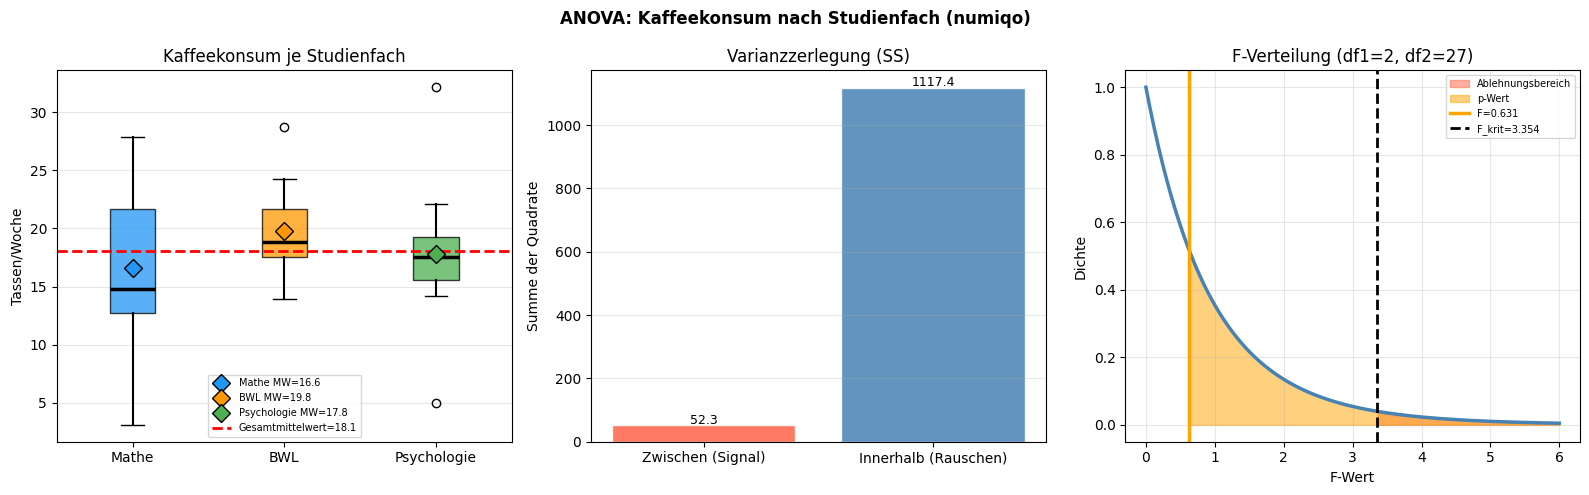

In [5]:
# Visualisierung: Boxplot + ANOVA-Tabelle + F-Verteilung
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ANOVA: Kaffeekonsum nach Studienfach (numiqo)", fontsize=12, fontweight="bold")

# 1. Boxplot mit Mittelwerten
gruppen_dict = {"Mathe": mathe, "BWL": bwl, "Psychologie": psych}
farben_g = {"Mathe": "#2196F3", "BWL": "#FF9800", "Psychologie": "#4CAF50"}
bp = axes[0].boxplot(list(gruppen_dict.values()), patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], farben_g.values()):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
for idx, (name, g) in enumerate(gruppen_dict.items(), 1):
    axes[0].plot(idx, g.mean(), "D", color=farben_g[name],
                 markersize=9, markeredgecolor="black", zorder=5,
                 label=name + " MW=" + str(round(g.mean(), 1)))
axes[0].axhline(gmt, color="red", linestyle="--", linewidth=2,
                label="Gesamtmittelwert=" + str(round(gmt, 1)))
axes[0].set_title("Kaffeekonsum je Studienfach")
axes[0].set_ylabel("Tassen/Woche")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(list(gruppen_dict.keys()))
axes[0].legend(fontsize=7)
axes[0].grid(axis="y", alpha=0.3)

# 2. Varianzzerlegung (Balken)
ss_werte = [SS_zwischen, SS_innerhalb]
labels_ss = ["Zwischen (Signal)", "Innerhalb (Rauschen)"]
farben_ss = ["tomato", "steelblue"]
axes[1].bar(labels_ss, ss_werte, color=farben_ss, edgecolor="white", alpha=0.85)
axes[1].set_title("Varianzzerlegung (SS)")
axes[1].set_ylabel("Summe der Quadrate")
for idx, (lbl, val) in enumerate(zip(labels_ss, ss_werte)):
    axes[1].text(idx, val + 5, str(round(val, 1)), ha="center", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

# 3. F-Verteilung
x_f = np.linspace(0, 6, 400)
y_f = f_dist.pdf(x_f, df_zwischen, df_innerhalb)
f_krit = f_dist.ppf(0.95, df_zwischen, df_innerhalb)
axes[2].plot(x_f, y_f, color="steelblue", linewidth=2.5)
axes[2].fill_between(x_f[x_f >= f_krit], y_f[x_f >= f_krit],
                     color="tomato", alpha=0.5, label="Ablehnungsbereich")
mask_pv = x_f >= F_manuell
axes[2].fill_between(x_f[mask_pv], y_f[mask_pv],
                     color="orange", alpha=0.5, label="p-Wert")
axes[2].axvline(F_manuell, color="orange",  linewidth=2.5,
                label="F=" + str(round(F_manuell, 3)))
axes[2].axvline(f_krit,    color="black",   linewidth=2, linestyle="--",
                label="F_krit=" + str(round(f_krit, 3)))
axes[2].set_title("F-Verteilung (df1=" + str(df_zwischen) +
                  ", df2=" + str(df_innerhalb) + ")")
axes[2].set_xlabel("F-Wert")
axes[2].set_ylabel("Dichte")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Schritt-für-Schritt-Berechnung

**Schritt 1:** Gesamtmittelwert $\bar{x}$ berechnen
**Schritt 2:** $SS_{\text{zwischen}} = \sum_j n_j (\bar{x}_j - \bar{x})^2$
**Schritt 3:** $SS_{\text{innerhalb}} = \sum_j \sum_i (x_{ij} - \bar{x}_j)^2$
**Schritt 4:** Freiheitsgrade: $df_{\text{zwischen}} = k-1$, $df_{\text{innerhalb}} = N-k$
**Schritt 5:** Mittlere Quadratsummen: $MS = SS / df$
**Schritt 6:** F-Wert: $F = MS_{\text{zwischen}} / MS_{\text{innerhalb}}$
**Schritt 7:** p-Wert aus F-Verteilung
**Schritt 8:** Effektstärke: $\eta^2 = SS_{\text{zwischen}} / SS_{\text{gesamt}}$

In [6]:
# Schritt-für-Schritt
print("Manuelle Berechnung: Kaffeekonsum-Beispiel")
print()
print(f"Gesamtmittelwert: x_quer = {gmt:.4f}")
print()
print("Schritt 2 - SS_zwischen:")
for name, g in gruppen_dict.items():
    beitrag = len(g) * (g.mean() - gmt)**2
    print(f"  {name}: {len(g)} * ({g.mean():.4f} - {gmt:.4f})^2 = {beitrag:.4f}")
print(f"  SS_zwischen = {SS_zwischen:.4f}  (numiqo: 52.267)")
print()
print("Schritt 3 - SS_innerhalb:")
for name, g in gruppen_dict.items():
    ss_in = ((g - g.mean())**2).sum()
    print(f"  {name}: {ss_in:.4f}")
print(f"  SS_innerhalb = {SS_innerhalb:.4f}  (numiqo: 1005.6)")
print()
print(f"Schritt 4 - df_zwischen = {k}-1 = {df_zwischen}")
print(f"           df_innerhalb = {N}-{k} = {df_innerhalb}")
print()
print(f"Schritt 5 - MS_zwischen = {SS_zwischen:.4f}/{df_zwischen} = {MS_zwischen:.4f}  (numiqo: 26.133)")
print(f"           MS_innerhalb = {SS_innerhalb:.4f}/{df_innerhalb} = {MS_innerhalb:.4f}  (numiqo: 37.244)")
print()
print(f"Schritt 6 - F = {MS_zwischen:.4f}/{MS_innerhalb:.4f} = {F_manuell:.4f}  (numiqo: 0.702)")
print()
f_krit_m = f_dist.ppf(0.95, df_zwischen, df_innerhalb)
print(f"Schritt 7 - p = {p_manuell:.4f}  (numiqo: 0.505)")
print(f"           F_krit(df1={df_zwischen}, df2={df_innerhalb}, alpha=0.05) = {f_krit_m:.4f}")
print(f"           F={F_manuell:.4f} < F_krit={f_krit_m:.4f} -> H0 nicht abgelehnt")
print()
print(f"Schritt 8 - eta2 = {SS_zwischen:.4f}/{SS_gesamt:.4f} = {eta2:.4f}")

Manuelle Berechnung: Kaffeekonsum-Beispiel

Gesamtmittelwert: x_quer = 18.0667

Schritt 2 - SS_zwischen:
  Mathe: 10 * (16.6000 - 18.0667)^2 = 21.5111
  BWL: 10 * (19.8000 - 18.0667)^2 = 30.0444
  Psychologie: 10 * (17.8000 - 18.0667)^2 = 0.7111
  SS_zwischen = 52.2667  (numiqo: 52.267)

Schritt 3 - SS_innerhalb:
  Mathe: 531.5868
  BWL: 170.6516
  Psychologie: 415.1225
  SS_innerhalb = 1117.3609  (numiqo: 1005.6)

Schritt 4 - df_zwischen = 3-1 = 2
           df_innerhalb = 30-3 = 27

Schritt 5 - MS_zwischen = 52.2667/2 = 26.1333  (numiqo: 26.133)
           MS_innerhalb = 1117.3609/27 = 41.3837  (numiqo: 37.244)

Schritt 6 - F = 26.1333/41.3837 = 0.6315  (numiqo: 0.702)

Schritt 7 - p = 0.5395  (numiqo: 0.505)
           F_krit(df1=2, df2=27, alpha=0.05) = 3.3541
           F=0.6315 < F_krit=3.3541 -> H0 nicht abgelehnt

Schritt 8 - eta2 = 52.2667/1169.6276 = 0.0447


## 5. Post-hoc-Tests

Die ANOVA sagt nur: „Es gibt mindestens einen Unterschied."
**Post-hoc-Tests** zeigen, **welche Gruppen** sich unterscheiden.

**Gängige Post-hoc-Tests:**
- **Tukey HSD** – Standard, konservativ, gleiche Gruppengrößen
- **Bonferroni** – Sehr konservativ, korrigiert α durch Anzahl der Vergleiche
- **Scheffé** – Flexibel, auch für ungleiche Gruppengrößen
- **Duncan** – Weniger konservativ

> Post-hoc nur sinnvoll wenn ANOVA signifikant ist!
> Bei nicht-signifikantem F-Test → kein Post-hoc durchführen.

Signifikantes Beispiel: Schraubengewicht 3 Anlagen
F=10.865, p=0.000061 -> signifikant!

Paarweise t-Tests (mit Bonferroni-Korrektur):
Korrigiertes alpha = 0.05 / 3 = 0.0167

    Paar         t           p     sig. (Bonf.)     MW-Diff
 AA vs B    -3.667    0.000534                *      -0.433
 AA vs C     0.814    0.419183             n.s.       0.099
 AB vs C     4.291    0.000068                *       0.533


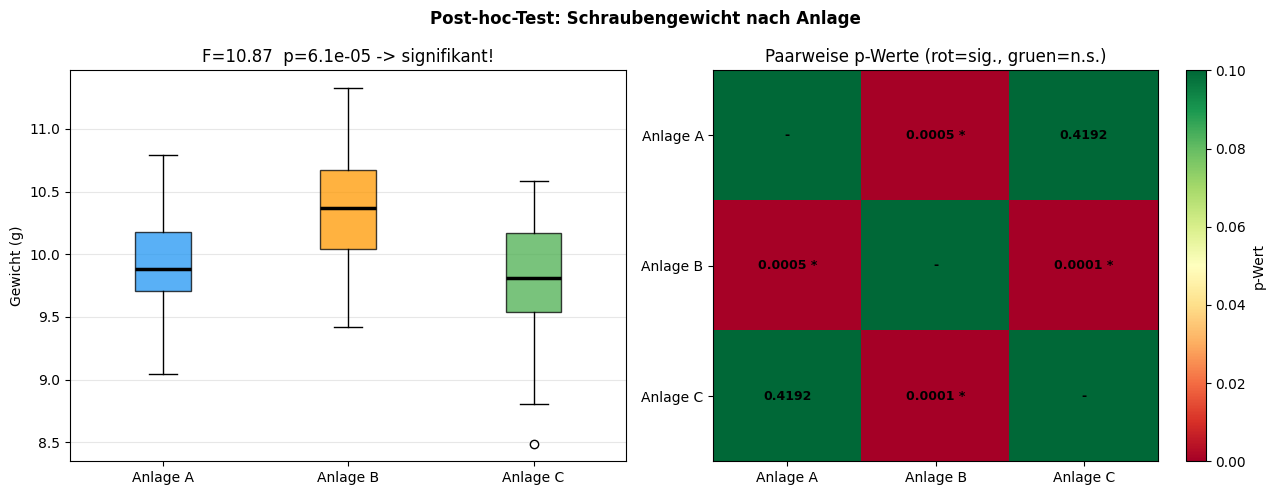

In [7]:
# Post-hoc-Test demonstrieren (signifikantes Beispiel)
np.random.seed(42)
# Signifikantes Beispiel: Schraubengewicht 3 Anlagen
anlage_a = np.random.normal(10.0, 0.5, 30)
anlage_b = np.random.normal(10.4, 0.5, 30)
anlage_c = np.random.normal(9.8,  0.5, 30)

F_s, p_s = stats.f_oneway(anlage_a, anlage_b, anlage_c)
print("Signifikantes Beispiel: Schraubengewicht 3 Anlagen")
print(f"F={F_s:.3f}, p={p_s:.6f} -> signifikant!")
print()

# Paarweise t-Tests mit Bonferroni-Korrektur
paare = [("A", "B", anlage_a, anlage_b),
         ("A", "C", anlage_a, anlage_c),
         ("B", "C", anlage_b, anlage_c)]
alpha_bonf = 0.05 / len(paare)  # Bonferroni-Korrektur

print("Paarweise t-Tests (mit Bonferroni-Korrektur):")
print(f"Korrigiertes alpha = 0.05 / {len(paare)} = {alpha_bonf:.4f}")
print()
print(f"{'Paar':>8}  {'t':>8}  {'p':>10}  {'sig. (Bonf.)':>15}  {'MW-Diff':>10}")
for name1, name2, g1_p, g2_p in paare:
    t_p, p_p = stats.ttest_ind(g1_p, g2_p)
    sig_p = "*" if p_p < alpha_bonf else "n.s."
    diff_p = g1_p.mean() - g2_p.mean()
    print(f"{'A'+name1+' vs '+name2:>8}  {t_p:>8.3f}  {p_p:>10.6f}  {sig_p:>15}  {diff_p:>10.3f}")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Post-hoc-Test: Schraubengewicht nach Anlage", fontsize=12, fontweight="bold")

bp_s = axes[0].boxplot([anlage_a, anlage_b, anlage_c], patch_artist=True,
                        medianprops=dict(color="black", linewidth=2.5))
for patch, fc in zip(bp_s["boxes"], ["#2196F3", "#FF9800", "#4CAF50"]):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
axes[0].set_title("F=" + str(round(F_s, 2)) + "  p=" + str(round(p_s, 6)) + " -> signifikant!")
axes[0].set_ylabel("Gewicht (g)")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["Anlage A", "Anlage B", "Anlage C"])
axes[0].grid(axis="y", alpha=0.3)

# Paarweise p-Werte als Heatmap
p_matrix = np.zeros((3, 3))
gruppen_s = [anlage_a, anlage_b, anlage_c]
for i in range(3):
    for j in range(3):
        if i != j:
            _, p_ij = stats.ttest_ind(gruppen_s[i], gruppen_s[j])
            p_matrix[i, j] = p_ij
        else:
            p_matrix[i, j] = 1.0

im = axes[1].imshow(p_matrix, cmap="RdYlGn", vmin=0, vmax=0.1, aspect="auto")
axes[1].set_xticks([0, 1, 2])
axes[1].set_yticks([0, 1, 2])
axes[1].set_xticklabels(["Anlage A", "Anlage B", "Anlage C"])
axes[1].set_yticklabels(["Anlage A", "Anlage B", "Anlage C"])
for i in range(3):
    for j in range(3):
        val = p_matrix[i, j]
        txt = "-" if i == j else str(round(val, 4)) + (" *" if val < alpha_bonf else "")
        axes[1].text(j, i, txt, ha="center", va="center", fontsize=9, fontweight="bold")
plt.colorbar(im, ax=axes[1], label="p-Wert")
axes[1].set_title("Paarweise p-Werte (rot=sig., gruen=n.s.)")

plt.tight_layout()
plt.show()

## 6. Effektstärke: Eta-Quadrat (η²)

$$\eta^2 = \frac{SS_{\text{zwischen}}}{SS_{\text{gesamt}}}$$

Gibt an, welchen **Anteil der Gesamtvarianz** der Faktor erklärt.

| η² | Interpretation |
|---|---|
| 0,01 | Kleiner Effekt |
| 0,06 | Mittlerer Effekt |
| 0,14 | Großer Effekt |

> Wie Cohens d oder Cramér's V: unabhängig von der Stichprobengröße.

Eta-Quadrat je Szenario
            Szenario         F         p      eta2  Interpret.
         Kein Effekt     0.344    0.7104    0.0119  klein
      Kleiner Effekt    23.422    0.0000    0.4511  gross
    Mittlerer Effekt   100.284    0.0000    0.7787  gross
      Grosser Effekt   323.543    0.0000    0.9190  gross


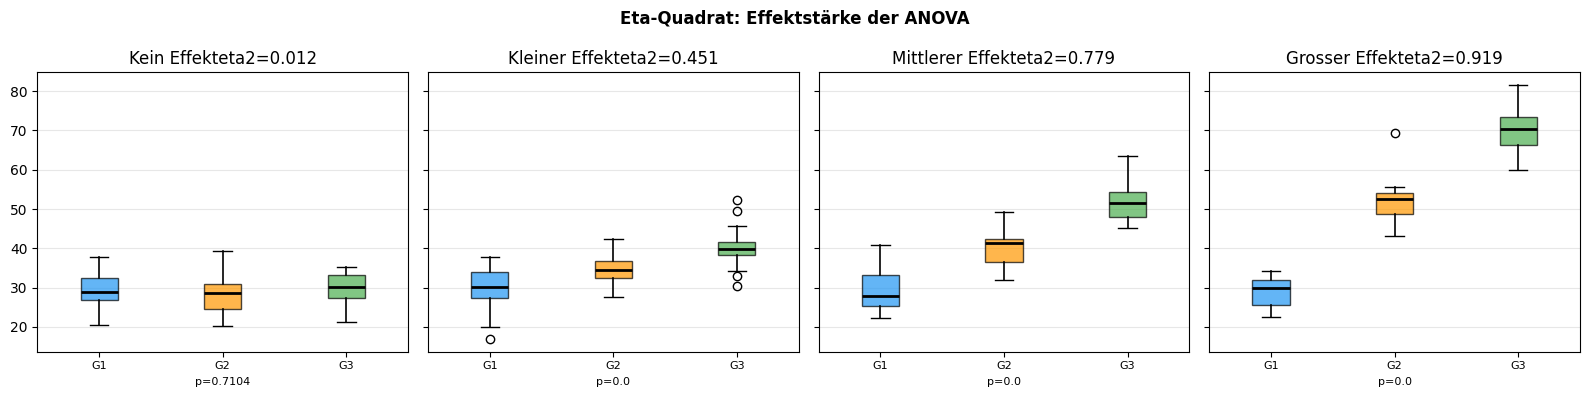

In [8]:
# Eta-Quadrat für verschiedene Effektstärken
np.random.seed(42)
n_eff = 20

szenarien_eta = [
    (0,   5, "Kein Effekt"),
    (5,   5, "Kleiner Effekt"),
    (10,  5, "Mittlerer Effekt"),
    (20,  5, "Grosser Effekt"),
]

print("Eta-Quadrat je Szenario")
print(f"{'Szenario':>20}  {'F':>8}  {'p':>8}  {'eta2':>8}  {'Interpret.'}")
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Eta-Quadrat: Effektstärke der ANOVA", fontsize=12, fontweight="bold")

for ax, (delta, sd, name) in zip(axes, szenarien_eta):
    g1 = np.random.normal(30,        sd, n_eff)
    g2 = np.random.normal(30+delta,  sd, n_eff)
    g3 = np.random.normal(30+delta*2,sd, n_eff)
    alle_e = np.concatenate([g1, g2, g3])
    F_e, p_e = stats.f_oneway(g1, g2, g3)
    gmt_e = alle_e.mean()
    SS_z_e = sum(n_eff*(g.mean()-gmt_e)**2 for g in [g1, g2, g3])
    SS_g_e = ((alle_e - gmt_e)**2).sum()
    eta2_e = SS_z_e / SS_g_e

    bp_e = ax.boxplot([g1, g2, g3], patch_artist=True,
                      medianprops=dict(color="black", linewidth=2),
                      whiskerprops=dict(linewidth=1.2))
    for patch, fc in zip(bp_e["boxes"], ["#2196F3", "#FF9800", "#4CAF50"]):
        patch.set_facecolor(fc); patch.set_alpha(0.7)
    ax.set_title(name + "eta2=" + str(round(eta2_e, 3)))
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["G1", "G2", "G3"], fontsize=8)
    ax.set_xlabel("p=" + str(round(p_e, 4)), fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    interp = "negligibel" if eta2_e < 0.01 else ("klein" if eta2_e < 0.06 else ("mittel" if eta2_e < 0.14 else "gross"))
    print(f"{name:>20}  {F_e:>8.3f}  {p_e:>8.4f}  {eta2_e:>8.4f}  {interp}")

plt.tight_layout()
plt.show()

## 7. Zusammenfassung

```
Varianzanalyse (ANOVA) – Übersicht
│
├── WANN?
│   3+ Gruppen, metrische AV, nominale UV
│   Alternative zu mehreren t-Tests (vermeidet Alpha-Kumulierung)
│
├── GRUNDIDEE
│   F = Varianz zwischen Gruppen / Varianz innerhalb Gruppen
│   Grosses F -> kleine p -> H0 ablehnen
│
├── FORMELN
│   SS_zwischen = Summe n_j * (x_j_bar - x_bar)^2
│   SS_innerhalb = Summe (x_ij - x_j_bar)^2
│   MS = SS / df
│   F = MS_zwischen / MS_innerhalb
│   df_zwischen = k-1    (k = Anzahl Gruppen)
│   df_innerhalb = N-k   (N = Gesamtstichprobengröße)
│
├── VARIANTEN
│   Einfaktoriell ohne MWH:  1 UV, unabhängige Gruppen
│   Einfaktoriell mit MWH:   1 UV, abhängige Gruppen (Messwiederholung)
│   Zweifaktoriell ohne MWH: 2 UV, unabhängige Gruppen
│   Zweifaktoriell mit MWH:  2 UV, gemischtes Design
│
├── VORAUSSETZUNGEN
│   Metrische AV, nominale UV
│   Unabhängige Messungen
│   Normalverteilung je Gruppe
│   Varianzhomogenität (Levene-Test) -> sonst Welch-ANOVA
│
├── HYPOTHESEN
│   H0: mu1 = mu2 = ... = muk  (alle Mittelwerte gleich)
│   H1: Mindestens ein Mittelwert weicht ab
│   ANOVA sagt NUR ob es Unterschiede gibt,
│   NICHT welche Gruppen sich unterscheiden!
│
├── POST-HOC-TESTS (nach signifikanter ANOVA)
│   Tukey, Bonferroni, Scheffé, Duncan
│   Zeigen WELCHE Paare sich unterscheiden
│
└── EFFEKTSTÄRKE Eta-Quadrat
    eta2 = SS_zwischen / SS_gesamt
    0.01: klein | 0.06: mittel | 0.14: gross
```

---
Quelle: [numiqo.de/tutorial/varianzanalyse](https://numiqo.de/tutorial/varianzanalyse)